# SQD for ATP

## Setup

In [1]:
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif"})
import numpy as np
import pickle

import openfermion as of

import qiskit
from qiskit import qasm2, qasm3
from qiskit_aer import AerSimulator
import qiskit_ibm_runtime
from qiskit_ibm_runtime import SamplerV2 as Sampler

In [2]:
use_initial_measurement: bool = True
use_dd: bool = True

In [3]:
ibm_computer: str = "ibm_boston"
# qubits = list(range(90))
# qubits.remove(46)
# qubits.remove(85)
# qubits = [56, 60, 61, 62, 63, 76] + [65, 66, 67, 68, 69] + [77, 78] + list(range(80, 156))
qubits = list(range(73))
# qubits.remove(85)
qubits.remove(46)
# qubits = list(range(36))
nshots: int = 500_000

nqubits = len(qubits)
nqubits

72

In [4]:
# Skip this cell if not running on hardware.
service = qiskit_ibm_runtime.QiskitRuntimeService(name="Q4BIOFLEX")
computer = service.backend(ibm_computer)
sampler = Sampler(computer)

## Read in the Hamiltonian and ansatz circuit

In [5]:
fragment = "atp_0_be2_f14"

adapt_iterations: int = 10

In [6]:
circuit_dir =  "circuits/truncated_pool"
circuit_fname = f"{fragment}_{adapt_iterations:03d}_adaptiterations.qasm"
circuit_path = f"{circuit_dir}/{fragment}/{circuit_fname}"
circuit_path

'circuits/truncated_pool/atp_0_be2_f14/atp_0_be2_f14_010_adaptiterations.qasm'

In [7]:
circuit = qasm3.load(circuit_path)
# circuit.draw(fold=-1, idle_wires=False)

In [8]:
len(circuit.qubits)

72

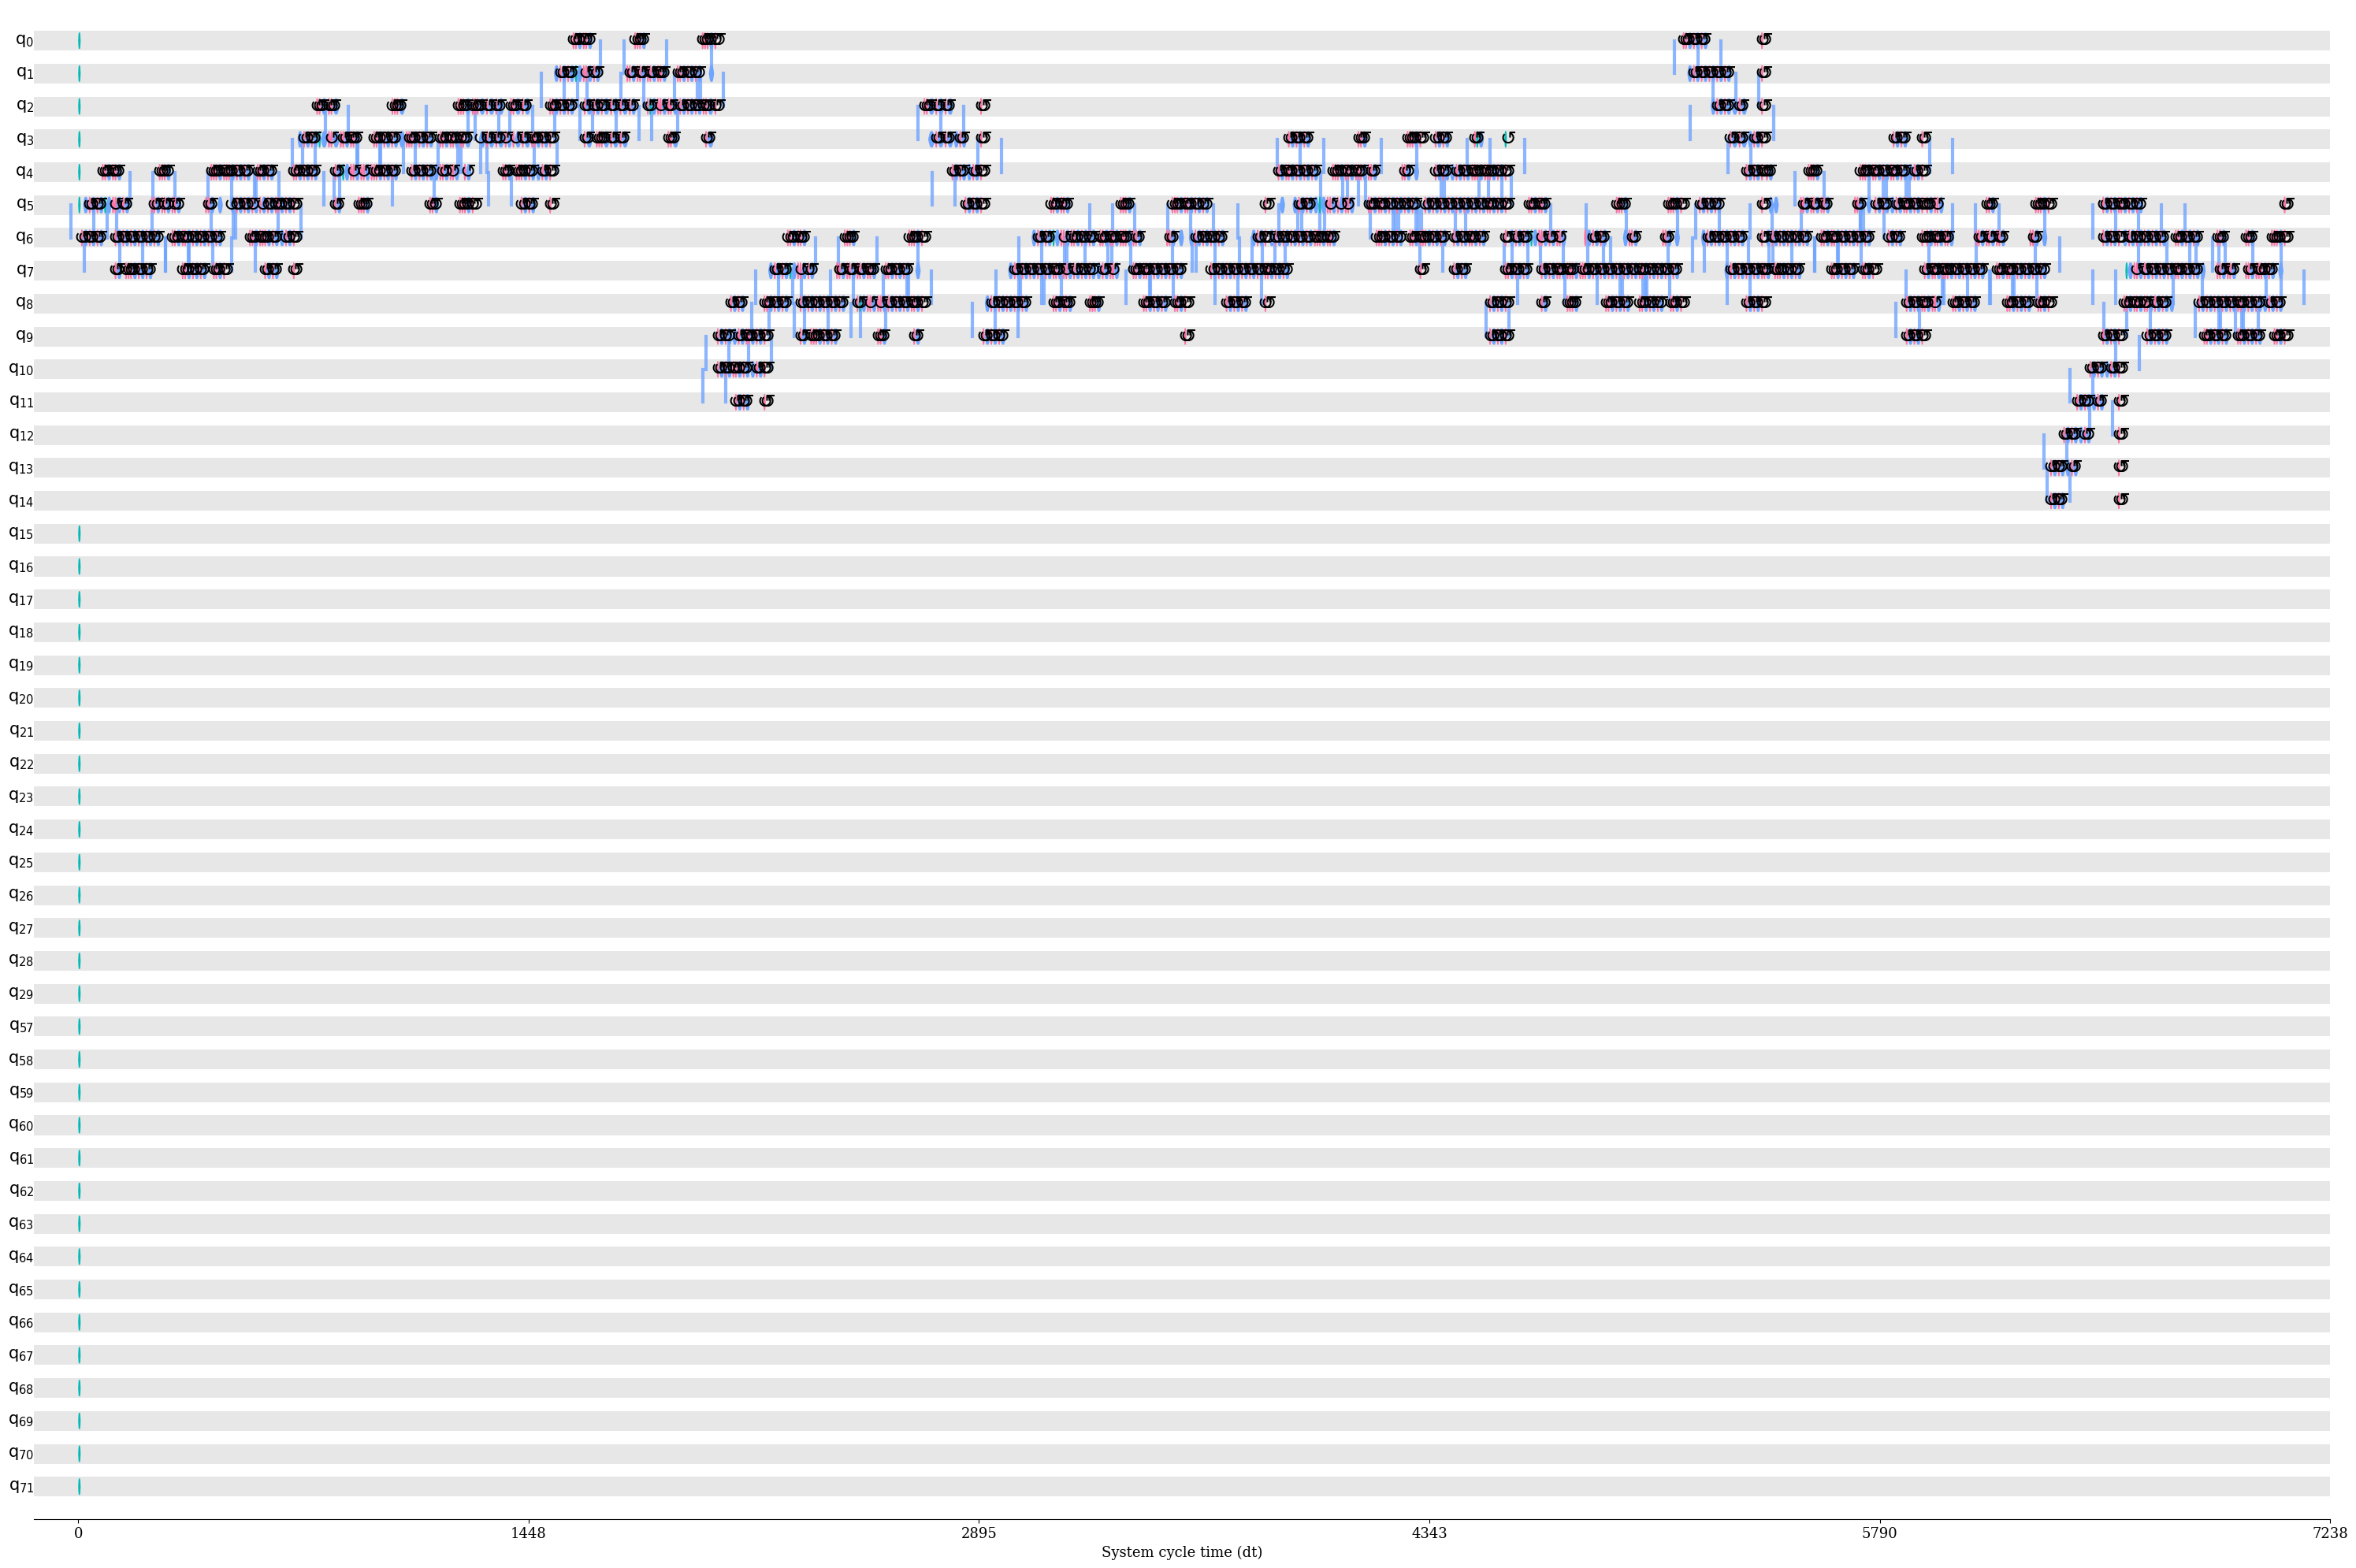

In [9]:
from qiskit.visualization import timeline_drawer
from qiskit.visualization.timeline.stylesheet import IQXStandard, IQXSimple, IQXDebugging

fig, ax = plt.subplots(figsize=(30, 20));

timeline_drawer(circuit, style=IQXSimple(), idle_wires=False, target=computer.target, axis=ax)

In [10]:
# TODO: Remove idle qubits.
from typing import Tuple, List, Dict
import qiskit

def remove_idle(circuit: qiskit.QuantumCircuit) -> Tuple[qiskit.QuantumCircuit, Dict[int, bool]]:
    candidates = circuit.qubits.copy() # List of qubits that are not entangled with the "bulk".
    for inst in circuit.data:
        if len(inst.qubits) == 2:
            q1, q2 = inst.qubits
            if q1 in candidates:
                candidates.remove(q1)
            if q2 in candidates:
                candidates.remove(q2)
    candidates = sorted(candidates, key=lambda x: x._index)
    not_candidates = list(set(circuit.qubits) - set(candidates))
    not_candidates = sorted(not_candidates, key=lambda x: x._index)

    qubits_to_bools = {}
    for inst in circuit.data:
        if len(set(inst.qubits) & set(candidates)) != 0:
            if inst.name == 'x':
                qubits_to_bools[inst.qubits[0]._index] = True
    for candidate in candidates:
        if candidate._index not in qubits_to_bools.keys():
            qubits_to_bools[candidate._index] = False

    new_ckt = qiskit.QuantumCircuit(not_candidates)
    for inst in circuit.data:
        if len(set(inst.qubits) & set(candidates)) == 0:
            new_ckt.append(inst, inst.qubits)
    return qubits_to_bools, new_ckt


qubits_to_bools, circuit = remove_idle(circuit)

TypeError: '<' not supported between instances of 'NoneType' and 'NoneType'

In [ ]:
# from qiskit.converters import circuit_to_dag, dag_to_circuit


# dag = circuit_to_dag(circuit)
# print(list(dag.idle_wires()))
# dag.remove_qubits(*list(dag.idle_wires()))
# circuit = dag_to_circuit(dag)

In [ ]:
base = circuit.copy()
base = qiskit.transpiler.passes.RemoveBarriers()(base)
base.count_ops()

## Prepare to run on hardware

In [ ]:
to_run = base.copy()

# Add initial measurement to post-select on all 0.
if use_initial_measurement:
    measure = to_run.copy_empty_like()
    measure.measure_all()
    measure.barrier()
    to_run = measure.compose(to_run)

# Terminal measurement.
to_run.measure_all()
to_run = [to_run]

In [ ]:
# to_run[0].draw(fold=-1)

In [ ]:
to_run = qiskit.transpile(
    to_run,
    optimization_level=3,
    backend=computer,
    initial_layout=qubits,
    seed_transpiler=123
)

In [ ]:
for c in to_run:
    print(c.count_ops())
    print(sum(v for k, v in c.count_ops().items() if k not in ("measure", "barrier")))

In [ ]:
to_run[0].depth()

In [ ]:
ops = list(to_run[0].count_ops().keys())
num = list(to_run[0].count_ops().values())

In [ ]:
sum([number for op, number in to_run[0].count_ops().items() if op != "cz"])

In [ ]:
ops = list(to_run[0].count_ops().keys())
num = list(to_run[0].count_ops().values())

plt.bar(ops, num, color="green", edgecolor="black")
plt.xlabel("Gate")
plt.ylabel("Count");

In [ ]:
to_run[0].draw(fold=-1)

In [ ]:
# from qiskit.visualization import timeline_drawer
# from qiskit.visualization.timeline.stylesheet import IQXStandard, IQXSimple, IQXDebugging

# fig, ax = plt.subplots(figsize=(30, 20));

# timeline_drawer(to_run[0], style=IQXSimple(), idle_wires=False, target=computer.target, axis=ax)

### Add DD

In [ ]:
to_run[0].depth()

In [ ]:
if use_dd:
    target = computer.target

    from qiskit.circuit.library import XGate, YGate

    X = XGate()
    Y = YGate()

    dd_sequence = [X, Y, X, Y] * (to_run[0].depth() // 400)

    from qiskit.transpiler import InstructionProperties

    y_gate_properties = {}
    for qubit in range(target.num_qubits):
        y_gate_properties.update(
            {
                (qubit,): InstructionProperties(
                    duration=target["x"][(qubit,)].duration,
                    error=target["x"][(qubit,)].error,
                )
            }
        )

    target.add_instruction(YGate(), y_gate_properties)

    from qiskit.transpiler import PassManager
    from qiskit.transpiler.passes.scheduling import (
        ALAPScheduleAnalysis,
        PadDynamicalDecoupling,
    )

    dd_pm = PassManager(
        [
            ALAPScheduleAnalysis(target=target),
            PadDynamicalDecoupling(target=target, dd_sequence=dd_sequence),
        ]
    )
    to_run_dd = dd_pm.run(to_run[0])

    # Hacky fix to compile Y gates to native gates.
    computer = service.backend(ibm_computer)
    sampler = Sampler(computer)

    from qiskit.circuit.equivalence_library import (
        SessionEquivalenceLibrary as sel,
    )
    from qiskit.transpiler.passes import BasisTranslator

    to_run_dd = BasisTranslator(sel, list(computer.target.operation_names))(to_run_dd)

    to_run_dd = [to_run_dd]

    labels = ["Raw", "DD (XYXY)"]

    circuits = [to_run[0], to_run_dd[0]]

    all_ops = sorted(set().union(*(c.count_ops().keys() for c in circuits)))

    x = np.arange(len(all_ops))
    width = 0.4
    for i, c in enumerate(circuits):
        counts = c.count_ops()
        aligned_counts = [counts.get(op, 0) for op in all_ops]
        
        x_shifted = x + (i - 0.5) * width
        plt.bar(x_shifted, aligned_counts, width=width,
                edgecolor="black", label=labels[i])

    plt.xticks(x, all_ops)
    plt.xlabel("Gate")
    plt.ylabel("Count")
    plt.legend();
    to_run = to_run_dd

In [ ]:
for c in to_run:
    print(c.count_ops())
    print(sum(c.count_ops().values()))
    print(sum({k: v for k, v in c.count_ops().items() if k not in ("delay", "barrier", "measure")}.values()))

In [ ]:
to_run[0].depth()

In [ ]:
from qiskit.visualization import timeline_drawer
from qiskit.visualization.timeline.stylesheet import IQXStandard, IQXSimple, IQXDebugging

fig, ax = plt.subplots(figsize=(30, 20));

timeline_drawer(to_run[0], style=IQXSimple(), idle_wires=False, target=computer.target, axis=ax)

In [ ]:
# to_run[0].draw(fold=-1, idle_wires=False)

## Run on exact simulator

In [ ]:
# to_run[0].draw(fold=-1)

In [ ]:
max_mps_bond: int = 128
simulator = AerSimulator(
    method="matrix_product_state",
    enable_truncation=True,
    zero_threshold=None,
    validation_threshold=None,
    matrix_product_state_max_bond_dimension=max_mps_bond,
    matrix_product_state_truncation_threshold=1e-5,
    chop_threshold=None,
)
result = simulator.run(to_run, shots=10_000)
counts_mps = result.result().get_counts()
counts_mps

In [ ]:
pickle.dump(counts_mps, open(fname + f"_mps_chi_{max_mps_bond}_counts", "wb"))

In [ ]:
classical = {}

In [ ]:
for bitstring, count in counts_mps.items():
    print(bitstring.split(" ")[0].count("1"))
    classical[bitstring.split(" ")[0]] = count

In [ ]:
classical

In [ ]:
# import qiskit.visualization


# qiskit.visualization.plot_histogram(
#     counts,
#     # target_string=hartree_fock_bitstring,
#     # sort="hamming",
#     number_to_keep=50,
#     figsize=(10, 15),
#     title=computer.name,
# )

In [ ]:
# hartree_fock_bitstring = list(counts.keys())[0]
# hartree_fock_bitstring

## Run on noisy simulator

In [ ]:
# sim = AerSimulator.from_backend(computer, method="matrix_product_state")

In [ ]:
# result = sim.run(to_run, shots=nshots)
# counts = result.result().get_counts()

In [ ]:
# qiskit.visualization.plot_histogram(
#     counts,
#     target_string=hartree_fock_bitstring,
#     sort="hamming",
#     number_to_keep=10,
#     figsize=(7, 8),
#     title=sim.name,
# )

## Run on hardware

In [ ]:
job = sampler.run(to_run, shots=nshots)
# job = service.job("d6u2l6atnsts73ermmq0")

In [ ]:
all_counts_hardware = []

In [ ]:
res = job.result()

In [ ]:
res[0].data

In [ ]:
# counts = pickle.load(open("./results/truncated_pool/atp_0_be2_f18/boston/dd_and_postselectprep/atp_0_be2_f18_005_adaptiterations.qasm_counts_ibm_boston_nshots_500000_2026_03_18_22-45-38_dd_postselectprep", "rb"))
# all_counts_hardware = [counts]

In [ ]:
# Post select all zero bitstrings on initial measurement.
if use_initial_measurement:
    r = res[0]
    imeas = r.data.meas

    imask = []
    for i, row in enumerate(imeas.to_bool_array()):
        if list(row) == [False] * nqubits:
            imask.append(i)
    print("Post-selection rate:", len(imask) / nshots)

    assert len(imask) == imeas.get_counts().get("0" * nqubits)
    assert not np.any(imeas[imask].to_bool_array())

In [ ]:
for r in res:
    if use_initial_measurement:
        all_counts_hardware.append(r.data.meas0[imask].get_counts())
    else:
        all_counts_hardware.append(r.data.meas.get_counts())

In [ ]:
len(all_counts_hardware[0])

In [ ]:
# probs_mps = {}
# shots_mps = sum(counts_mps.values())
# shots_qpu = sum(all_counts_hardware[0].values())

# xeb = 0.0
# kl = 0.0
# for bitstring, count in counts_mps.items():
#     print(bitstring, count)
#     prob_mps = count / shots_mps
#     print("Hamming weight:", bitstring.count("1"))

#     prob_qpu = all_counts_hardware[0].get(bitstring, 0) / shots_qpu
#     print("prob_mps", prob_mps)
#     print("prob_qpu", prob_qpu)
#     if prob_qpu > 1e-8:
#         xeb -= prob_mps * np.log(prob_qpu)
#         kl += prob_mps * np.log(prob_mps / prob_qpu)
# print(xeb)
# print(kl)

In [ ]:
hamming_weight = 36
num_correct_hamming_weight = 0
hamming_weights = []
for bitstring, count in all_counts_hardware[0].items():
    hamming_weights.append(bitstring.count("1"))
    if bitstring.count("1") == hamming_weight:
        num_correct_hamming_weight += count
num_correct_hamming_weight / sum(all_counts_hardware[0].values())

In [ ]:
counts = np.bincount(hamming_weights)
fractions = counts / counts.sum()
x = np.arange(len(counts))
plt.figure(figsize=(12, 5))
plt.bar(x, fractions, width=0.8, align='center')
plt.xlabel("Fermion Number")
plt.ylabel("Fraction")

min_hw = min(hamming_weights)
max_hw = max(hamming_weights)
plt.xlim(min_hw - 0.5, max_hw + 0.5)
plt.xticks(np.arange(min_hw, max_hw + 1))

plt.title(circuit_fname + f"_counts_{computer.name}_nshots_{nshots}" + "_dd" * use_dd + "_postselectprep" * use_initial_measurement)
plt.axvline(hamming_weight, label="Correct Fermion Number", color="xkcd:green")
plt.legend()
plt.show();

In [ ]:
import qiskit.visualization


qiskit.visualization.plot_histogram(
    all_counts_hardware[0],
    # target_string=hartree_fock_bitstring,
    # sort="hamming",
    number_to_keep=50,
    figsize=(10, 15),
    title=computer.name,
)

## Save data

In [ ]:
import datetime


time_key = datetime.datetime.now().strftime("%Y_%m_%d_%H-%M-%S")
fname = circuit_fname + f"_counts_{computer.name}_nshots_{nshots}_{time_key}" + "_dd" * use_dd + "_postselectprep" * use_initial_measurement
fname

In [ ]:
pickle.dump(all_counts_hardware[0], open(fname, "wb"))

## Run SQD

In [ ]:
import pyscf.tools
from pyscf import ao2mo

import collections
from functools import partial
import os
import pickle

from qiskit.primitives import BitArray
from qiskit_addon_sqd.fermion import SCIResult, diagonalize_fermionic_hamiltonian, solve_sci_batch

In [ ]:
mode_order = pickle.load(
    open(f"{circuit_dir}/{fragment}/{fragment}_mode_order_{adapt_iterations:03d}_adaptiterations.pkl", "rb")
)
qubit_order = pickle.load(
    open(f"{circuit_dir}/{fragment}/{fragment}_qubit_order_{adapt_iterations:03d}_adaptiterations.pkl", "rb")
)

In [ ]:
hamiltonian_dir = "hamiltonians"

In [ ]:
fcidump = pyscf.tools.fcidump.read(f"{hamiltonian_dir}/{fragment}.fcidump")

In [ ]:
n_orbitals = fcidump.get("NORB")
num_electrons = fcidump.get("NELEC")
ecore = fcidump.get("ECORE")
h1 = fcidump.get("H1")
h2 = fcidump.get("H2")
h2 = ao2mo.restore(1, h2, n_orbitals)

In [ ]:
num_electrons

In [ ]:
energy_tol = 1e-8
occupancies_tol = 1e-8
carryover_threshold = 1e-5

In [ ]:
fname = "atp_0_be2_f2_010_adaptiterations.qasm_counts_ibm_fez_nshots_100000_2026_02_24_00-01-41"

In [ ]:
counts = pickle.load(
    open(f"results/{fragment}/{fname}", "rb")
)

In [ ]:
counts = collections.Counter(all_counts_hardware[0])
for cb, cc in classical.items():
    counts[cb] += cc

In [ ]:
assert sum(counts.values()) == sum(all_counts_hardware[0].values()) + sum(classical.values())

In [ ]:
def transform_bitstring(bits):
    """
    Convert a given bitstring from Openfermion convention 
    (alternating alpha/beta, big endian) to Qiskit (all alpha
    then all beta, little endian).
    """

    left = [bits[i] for i in range(len(bits)) if i % 2 == 1]   # beta
    right = [bits[i] for i in range(len(bits)) if i % 2 == 0]  # alpha

    # Reverse each half
    left.reverse()
    right.reverse()

    # Concatenate
    return ''.join(left + right)

In [ ]:
measurement_outcomes = counts
permuted_outcomes = {}
for original_bitstring in measurement_outcomes.keys():
    qubit_permuted_bitstring = "".join([original_bitstring[qubit_order.index(n)] for n in range(nqubits)])
    mode_permuted_bitstring = "".join([qubit_permuted_bitstring[mode_order.index(n)] for n in range(nqubits)])

    final_permuted_bitstring = transform_bitstring(mode_permuted_bitstring)
    permuted_outcomes[final_permuted_bitstring[::]] = measurement_outcomes[original_bitstring]

bit_array = BitArray.from_counts(permuted_outcomes)
counts = bit_array.get_counts()
max_key = max(counts, key=counts.get)
print(f'Most common bitstring: {max_key} with count {counts[max_key]}')
print(f'Total number of bitstrings: {len(counts)}')
print(f"Total number of samples:", sum(counts.values()))

In [ ]:
sci_solver = partial(solve_sci_batch, spin_sq=0, max_cycle=10000)
result_history = []

def callback(results: list[SCIResult]):
    result_history.append(results)
    iteration = len(result_history)
    print(f"Iteration {iteration}")
    for i, result in enumerate(results):
        print(f"\tSubsample {i}")
        print(f"\t\tEnergy: {result.energy + ecore}")
        print(f"\t\tSubspace dimension: {np.prod(result.sci_state.amplitudes.shape)}")


result = diagonalize_fermionic_hamiltonian(
    one_body_tensor=h1,
    two_body_tensor=h2,
    bit_array=bit_array,
    samples_per_batch=500,
    norb=n_orbitals,
    nelec=(num_electrons // 2, num_electrons // 2),
    num_batches=2,
    energy_tol=energy_tol,
    occupancies_tol=occupancies_tol,
    max_iterations=100,
    sci_solver=sci_solver,
    symmetrize_spin=True,
    carryover_threshold=carryover_threshold,
    callback=callback,
)